<font color=#009afa size=50>DAT5004-Big Data Management Systems</font>

<font size=50 color=#00c382>Task One - Web Scraping Task</font><br>
<font size=35>Extracting Movie Information from FilmCrave.com</font>

**Assessment Code:** PRAC1 (Task 1)

**Author:** Tom Rowan, ST20285213

**Course:** DAT5004_S2_24

**Course Tutor:** Dr. Sandeep Singh Sengar

<p>

<img src=https://datascience.daemonchild.com/year2/dat5004/prac1/images/filmcrave-logo.png />

> FilmCrave (https://www.filmcrave.com/list_top_movie.php) is a website where people share their favourite
movies, reviews, and ratings. It has a huge collection of films, complete with rankings, genres, and other details.

> The goal of this project is to gather information on over 1,000 movies from this site. The data we want includes the
Year of Release, Overall Rating, Language, Genre, MPAA Rating (like PG or R), Director, Actors, and a short Plot
summary.

> To do this, you’ll use Python. A tool called BeautifulSoup will help you read and understand the webpage's layout
to pull out the data we need. Another tool, Requests, will help you connect to the website and fetch its content.
Once you have the data, you’ll use Pandas to organise it neatly into a table format, and then save it as a CSV file.
After gathering the data, you’ll clean it up, fix any missing or incorrect values, and make sure everything is
consistent. Then, you’ll analyse it. you’ll create visual charts, like bar graphs showing popular genres or line graphs
tracking how movie ratings have changed over time, using tools like Matplotlib and Seaborn. This project will
teach valuable skills in web scraping, data organisation, and analysis.

## Install and Import Required Libraries

In [ ]:
%pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [1]:
# BeautifulSoup and Requests
from bs4 import BeautifulSoup
import requests

# Pandas and numpy
import pandas as pd
import numpy as np

# Matplot Lib
import matplotlib.pyplot as plt
from matplotlib import colormaps
from matplotlib.pyplot import figure
%matplotlib inline

# Seaborn Graphs
import seaborn as sns

# Tabulate
from tabulate import tabulate

# Pillow
from PIL import Image

# Wordcloud
from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator

# Unidecode
from unidecode import unidecode
import chardet

# Random
import random

# OS
import os

# Do not print warnings!
import warnings
warnings.filterwarnings('ignore')

### Site Friendly Behaviour

Scraping a large amount of data from a website like FilmCrave.com may be seen as unfriendly behaviour by the site admins. Continually scraping large amounts of data from the site could result in a source IP address being banned. 

 

There are several reasons for this. One is because there is a financial implication each time the website retrieves data from the database, generates a page and delivers the data to a browser. CPU processing time and bandwidth must be paid for, particularly if the website is hosted within a cloud provider such as Microsoft Azure, Amazon AWS or Google Compute Platform. Furthermore, the data belongs to the site and there may be a perception that scraping this data is equivalent to theft. 


To minimise the impact against the website, I have run the full data scraping exercise to collect 1000 movies worth of data only a single time and saved the data into a CSV file to accompany this Jupyter notebook (movie_data.csv). 

 

When following variable '_FULL_WEB_SCRAPE_' is set to False, only a minimal scraping exercise will be run as a proof of concept. Then, the data from the CSV file will be loaded for the analysis phase.  

 

If this variable is set to True, the full exercise will be run. This takes a long time – around 15 to 20 minutes, depending on how the FilmCrave website responds - and will generate a large amount of traffic and hits against the target. 


To minimise the possibility of detection, the code below can utilise a web proxy to effectively hide the IP address of the python client. 

In [2]:
_FULL_WEB_SCRAPE_ = False

<font size=30 color=#00c382>Define Functions</font><br>

## Fetch Page Content Safely

The fetch_page function collects the HTML content for a page. It checks that the page has been returned correctly. 

The FilmCrave website responds with a 404 code when there is no movie data at a given URL. Furthermore, the web request is included within a Try/Except block to catch any web site related errors or connectivity issues. 

In [3]:
def fetch_page (url, http_proxy = None):
    html_content = ""
    try:
        if http_proxy is None:
            response = requests.get(url)
        else:
            proxies = {'http': http_proxy}
            response = requests.get(url, proxies = proxies)
        if response.status_code == 200:
            html_content = str(response.content)
    except:
        html_content = ""
    return html_content

In [4]:
def fetch_proxy_list (proxy_list_url="https://raw.githubusercontent.com/proxifly/free-proxy-list/refs/heads/main/proxies/countries/GB/data.txt"):

    # Fetch the list of proxies
    all_proxies = []
    http_proxies = []
    response = requests.get(proxy_list_url)
    if response.status_code == 200:
        all_proxies = response.text.split("\n")

    else:
        print ("Failed to fetch proxies.")

    for proxy in all_proxies:
        if proxy.startswith("http"):
            http_proxies.append(proxy)

    return http_proxies

## Parse Movie Data from Downloaded 

Each movie on the website has an individual page to display basic movie information and a list of more detailed reviews below. 

<img src="https://datascience.daemonchild.com/year2/dat5004/prac1/images/wrath_of_khan_1.png" />

In the 'parse_movie_data' function below, I am using BeautifulSoup to parse the HTML content returned from the website for each movie. The following HTML is a snippet from https://www.filmcrave.com/movie_page_main.php?id=10498, which refers to "Star Trek II: The Wrath of Khan". 

The HTML code defines a number of paragraphs, which we can use to search for each of the data fields. Note that the rank and rating fields are wrapped in an 'orange-bold' class, whereas the remaining data fields are not. The image above shows where the orange text is displayed.

<img src="https://datascience.daemonchild.com/year2/dat5004/prac1/images/wrath_of_khan_2_dark.png" />

In [5]:

def parse_movie_data (html_content):
    
    # Create blank dictionary
    movie_data = {
        'title': "Unknown",
        'overall_rank': 0,
        'average_rating': 0.0,
        'theatrical_release_date': "",
        'language': "",
        'genre': "",
        'mpaa_rating': "",
        'director': "",
        'actors': "",
        'url': ""
    }
    
    # Create Soup using HTML Parser
    soup = BeautifulSoup(html_content, 'html.parser')

    # Extract movie title from the meta tags
    meta_tags = soup.find_all('meta', property=True)
    for tag in meta_tags:
        property_name = tag.get('property')
        if property_name == "og:title":
            movie_data['title'] = tag.get('content')
            break
        
    # The rank and rating fields are wrapped in an 'orange-bold' class.
    # The lambda function is used to search for the text that contains the keyword/phrase.
    # If the BeautifulSoup search fails, set the value to zero.
    try:
        movie_data['overall_rank'] = int(soup.find('span', string=lambda x: x and 'Overall Rank:' in x).find_next('span', {'class': 'orange-bold'}).string.split("/")[0])
        movie_data['average_rating'] = float(soup.find('span', string=lambda x: x and 'Average Rating:' in x).find_next('span', {'class': 'orange-bold'}).string.split("/")[0])
    except:
        movie_data['overall_rank'] = 0
        movie_data['average_rating'] = 0.0
    
    # These keywords can be used to extract the rest of the data from the HTML content.
    keywords = [
            'Theatrical Release Date',
            'Language',
            'Genre',
            'MPAA Rating',
            'Director',
            'Actors',
            'Plot'
        ]
    
    # If the search fails, change the text to "Unknown"
    for keyword in keywords:
        search_word = keyword + ": "
        key = keyword.replace(' ','_').lower()
        try:
            movie_data[key] = soup.find('span', string=lambda x: x and search_word in x).next_sibling.strip()
        except:
            movie_data[key] = "Unknown"

    return movie_data

## Fetch a Number of Pages from the Top Movie List

The website provides a Top Movies list, where “[the] list is calculated by community movie ratings and members' Top Movies List.” This list is presented across 100 pages, with ten movies per page. I am using these Top Movie pages to create a list of URLs that point to the individual movie information pages. 

Here is an example showing the first few movies on one of the pages. Note that the URL contains a ‘page’ parameter which I increment to visit each of the 100 pages in turn.

<img src="https://datascience.daemonchild.com/year2/dat5004/prac1/images/top_movies_page_69.png" />

I use BeautifulSoup to parse the page and collect URLs for movie data. Interestingly enough, there are more than 10 movie links per page, as some are also collected from the side bar under "What Members Are Doing", as shown in the image above.

In [6]:
def fetch_n_pages_of_top_movie_urls (num_pages, use_proxies = False):
    
    # The Top Movies List provides at least 10 movies per page
    # There is a side bar to consider under the header "What Members Are Doing".

    # Fetch proxies if required
    if use_proxies:
        http_proxies = fetch_proxy_list()
        http_proxy = http_proxies[0]
    else:
        http_proxy = None

    print ("proxy ", http_proxy)

    # list of urls
    urls = []
    
    website = "https://www.filmcrave.com"
    base_url = website + "/list_top_movie.php?page="
    
    print (f"Fetching page: ",end="")
    for page in range(1, num_pages+1):

        # Print the page number that we are working on
        print (page, end="")
        
        # Fetch the page using safe function (above)
        url = base_url + str(page)
        html_content = fetch_page (url, http_proxy=http_proxy)

        if len(html_content) > 0:
            print (" [OK]", end="")

            # Get links from the page
            soup = BeautifulSoup(html_content, 'html.parser')
            links = soup.find_all('a')

            for link in links:
                href = link.get('href')
                if href:

                    # Check if the link is a movie detail page and add to the list of URLs
                    if "movie_page_main" in str(href):
                        movie_url = website + str(href)
                        urls.append (movie_url)

        else:
            print (" [FAIL]")
        
        # Print a comma if there are more pages
        if page < num_pages:
            if page % 10 == 0:
                print ("", end="\n")
            else:
                print (", ", end="")
        else:
            print (" Finished!")
            
    # Deduplicate URL list before returning it            
    urls= list(dict.fromkeys(urls))
    return (urls)

## Get movie data from a list of URLs

In [7]:
def fetch_movie_data_from_urls (urls, use_proxies=False):
    
    # Create an empty list to store the movie data
    movie_list = []
    num_pages = len(urls)
    page = 1

    # Fetch proxies if required
    if use_proxies:
        http_proxies = fetch_proxy_list()
        random_number = random.randint(0, len(http_proxies)-1)
        http_proxy = http_proxies[random_number]
        print ("Using Proxy ", http_proxy)
    else:
        http_proxy = None

    print (f'Fetching movie data for {num_pages} movies. This may take a long time!')

    print (f"Fetching page: ",end="")
    for url in urls:

        # Print the page number that we are working on
        print (page, end="")

        # Fetch the page content
        html_content = fetch_page(url, http_proxy)

        if len(html_content) > 0:
            
            # Parse the movie data from the page
            movie_data = parse_movie_data (html_content)

            # Check that we got at least some valid data
            if movie_data['title'] != "Unknown":
                movie_data['url'] = url
                movie_list.append(movie_data)
                print (" [OK]", end="")
            else:
                print (" [FAIL]", end="")
        # If it fails, try using a different proxy
        else:
            if use_proxies:
                random_number = random.randint(0, len(http_proxies)-1)
                http_proxy = http_proxies[random_number]
                print (" [P]", end="")

        # Print a comma if there are more pages
        if page < num_pages:
            if page % 10 == 0:
                print ("", end="\n")
            else:
                print (", ", end="")
        else:
            print (" Finished!")
            
        # Increment the page counter
        page += 1        
    
    return movie_list

This function creates a range of urls.

In [8]:
def generate_movie_urls (start, number):
    
    # list of urls
    urls = []
    
    website = "https://www.filmcrave.com"
    base_url = website + "/movie_page_main.php?id="


    for id in range(start,start+number):
        url = base_url + str(id)
        urls.append (url)

    return (urls)


### Collect ALL Movie data

There is also code below to generate 1000's of URLs, and to collect the results. There are two functions provided - one to scrape the data and another to produce a single dataframe.

This code works by fetching a batch of 1000 URLs and saving it out to a CSV file. This was done to allow a manually restartable batch run in case something went wrong (for example, a lost Internet connection.)

The second function recombines the CSV files into a dataframe.

In [9]:
# Generate a HUGE number of movies
# This will take many hours to complete!

def scrape_entire_movie_database_to_csv ():

    # Investigation shows that the movies start at id 2455
    urls = generate_movie_urls (start=2455, number=64000)

    num_urls = len(urls)

    # Run scraping in batches of 1000
    for i in range (0,num_urls,1000):
        
        # Extract 1000 URLs, and fetch the data
        movie_list = fetch_movie_data_from_urls (urls[i:i+1000], use_proxies=True)

        # Save out the data to a CSV file
        df = pd.DataFrame(movie_list)
        df.to_csv('movie_data'+str(i)+'.csv',index = False)


def build_dataframe_from_csv ():

    # Load the first CSV file
    build_df = pd.read_csv('movie_data0.csv')

    # Load the rest and concatenate them with the first one
    for i in range (1,63):
        filename = 'movie_data'+str(i*1000)+'.csv'
        print (filename)
        new_df = pd.read_csv(filename)
        build_df = pd.concat([build_df,new_df])

        # Drop duplicates
        build_df = build_df.drop_duplicates(subset=['title'], keep='first')
        build_df.to_csv('movie_data_complete.csv',index = False)

    return build_df


<font size=30 color=#00c382>Fetch Movie Data and Parse</font><br>

## Fetch 100 pages from the "Top Movies" list
Having defined functions to do the hard work, we can now collect the data.

This collects a list of 1000+ URLs for the top movies. This will take appox 4 minutes to run for all the 100 pages.

Remember that when the following variable '_FULL_WEB_SCRAPE_' is set to False, only a minimal scraping exercise will be run as a proof of concept (a single page).


In [10]:
if _FULL_WEB_SCRAPE_:
    urls = fetch_n_pages_of_top_movie_urls (num_pages=100, use_proxies=True)
else:
    urls = fetch_n_pages_of_top_movie_urls (num_pages=1, use_proxies=True)

proxy  http://164.38.155.24:80
Fetching page: 1 [OK] Finished!


In [19]:
# Testing

urls = fetch_n_pages_of_top_movie_urls (num_pages=10, use_proxies=True)

proxy  http://164.38.155.24:80
Fetching page: 1 [OK], 2 [OK], 3 [OK], 4 [OK], 5 [OK], 6 [OK], 7 [OK], 8 [OK], 9 [OK], 10 [OK] Finished!


## Fetch the actual movie data
This collects data for each of the movies by scraping data from each URL in the list.

For 1000 movies, this will take approx 8-10 minutes to run.

The movie_list list is then converted into a pandas dataframe.

In [20]:
movie_list = fetch_movie_data_from_urls (urls=urls,use_proxies=True)
df = pd.DataFrame(movie_list)

Using Proxy  http://164.38.155.55:80
Fetching movie data for 108 movies. This may take a long time!
Fetching page: 1 [OK], 2 [OK], 3 [OK], 4 [OK], 5 [OK], 6 [OK], 7 [OK], 8 [OK], 9 [OK], 10 [OK]
11 [OK], 12 [OK], 13 [OK], 14 [OK], 15 [OK], 16 [OK], 17 [OK], 18 [OK], 19 [OK], 20 [OK]
21 [OK], 22 [OK], 23 [OK], 24 [OK], 25 [OK], 26 [OK], 27 [OK], 28 [OK], 29 [OK], 30 [OK]
31 [OK], 32 [OK], 33 [OK], 34 [OK], 35 [OK], 36 [OK], 37 [OK], 38 [OK], 39 [OK], 40 [OK]
41 [OK], 42 [OK], 43 [OK], 44 [OK], 45 [OK], 46 [OK], 47 [OK], 48 [OK], 49 [OK], 50 [OK]
51 [OK], 52 [OK], 53 [OK], 54 [OK], 55 [OK], 56 [OK], 57 [OK], 58 [OK], 59 [OK], 60 [OK]
61 [OK], 62 [OK], 63 [OK], 64 [OK], 65 [OK], 66 [OK], 67 [OK], 68 [OK], 69 [OK], 70 [OK]
71 [OK], 72 [OK], 73 [OK], 74 [OK], 75 [OK], 76 [OK], 77 [OK], 78 [OK], 79 [OK], 80 [OK]
81 [OK], 82 [OK], 83 [OK], 84 [OK], 85 [OK], 86 [OK], 87 [OK], 88 [OK], 89 [OK], 90 [OK]
91 [OK], 92 [OK], 93 [OK], 94 [OK], 95 [OK], 96 [OK], 97 [OK], 98 [OK], 99 [OK], 100 [OK]
101

In [21]:
df.to_csv('movie_data_100_utf8.csv',index = False, encoding="utf-8")


### Collect Entire Movie Database

Using the additional functions above, it is possible to generate a complete scrape of all the movies in the database. This takes around **eight hours** to run! It is suggested that you do not do this. The results of s single run have been saved into a CSV file called movie_data_complete.csv.

In [12]:
# Commend out the following line to avoid accidentally running the full scrape

# scrape_entire_movie_database_to_csv()
# df = build_dataframe_from_csv()

<font size=30 color=#00c382>Analyse and Display the Data</font><br>

Using a dataframe allows me to add some more features to the data much more easily than manipulating a python list object.

I have engineered the following features from the data:

- Release Year (extracted from release date)
- Decade (movies from the 60's, 70's etc)
- Primary and Secondary Genre

In [13]:
# Load the complete dataset if available
if os.path.exists('movie_data_complete.csv'):
    print ("Loading complete dataset")
    df = pd.read_csv('movie_data_complete.csv', encoding="utf-8")
    df.to_csv('movie_data_test.csv',index = False, encoding="utf-8")

    df = pd.read_csv('movie_data_test.csv', encoding="utf-8")


Loading complete dataset


In [14]:
# Ensure that we only have the top 1000 movies
# df = df[df['overall_rank'] < 1001]

# Some of the dates were not parsed correctly, so can be fixed here

# **** MORE INVESTIGATION HERE ****

df['theatrical_release_date'] = pd.to_datetime(df['theatrical_release_date'], errors='coerce')

# Extract the year and calculate the decade

df['year'] = pd.DatetimeIndex(df['theatrical_release_date']).year
df['year'] = df['year'].fillna(2099).astype(int)
df['decade'] = (df['year'] // 10) * 10


# Genre
df.rename(columns={'genre': 'genres'}, inplace=True)
df['genre_main'] = df['genres'].str.split(',').str[0]
df['genre_secondary'] = df['genres'].str.split(',').str[1]
df.drop(columns={'genres'}, inplace=True)

# Extract filmcrave ID from URL
df['filmcrave_id'] = df['url'].str.split('=').str[1].astype(int)
df.drop(columns={'url'}, inplace=True)


# Create a Top 1000 Movies Dataframe
df_top1000 = df[df['overall_rank'] < 1001]


In [15]:
df['uni_title1'] = df['title'].apply(lambda x: x.encode('utf-8').decode('windows-1252').encode('utf-8').decode('unicode_escape'))
df['uni_title2'] = df['uni_title1'].apply(lambda x: unidecode(x))
text = df[df['filmcrave_id'] == 53099]['uni_title1'].values[0]
print (text)
text = df[df['filmcrave_id'] == 53099]['uni_title2'].values[0]
print (text)

After the Ball, the Bath ( AprÃ¨s le bal )
After the Ball, the Bath ( AprA"s le bal )


In [16]:
mystr1 = 'After the Ball, the Bath ( Apr\xc3\xa8s le bal )'
mystr1 = 'Breathless ( \xc3\x80 Bout de souffle )'
mystr1 = '18 ans apr\xc3\xa8s'
mystr2 = df[df['filmcrave_id'] == 2476]['title'].values[0]
print (type(mystr1))
print (type(mystr2))

print (mystr1)
print (mystr2)

astr1 = mystr1.encode('utf-8').decode('unicode_escape')
astr2= mystr2.encode('utf-8').decode('unicode_escape')

#astr1 = mystr1.encode('utf-8').decode('unicode_escape').encode("windows-1252").decode("utf-8")
#astr2= mystr2.encode('utf-8').decode('unicode_escape').encode("windows-1252").decode("utf-8")
print (astr1)
print (astr2)

print (unidecode(astr1))
print (unidecode(astr2))




<class 'str'>
<class 'str'>
18 ans aprÃ¨s
18 ans apr\xc3\xa8s
18 ans aprÃÂ¨s
18 ans aprÃ¨s
18 ans aprAA"s
18 ans aprA"s


In [17]:
df['uni_title1'] = df['title'].apply(lambda x: x.encode('windows-1252').decode('utf-8').encode('utf-8').decode('unicode_escape'))
df['uni_title2'] = df['uni_title1'].apply(lambda x: unidecode(x))
text = df[df['filmcrave_id'] == 53099]['uni_title1'].values[0]
print (text)
text = df[df['filmcrave_id'] == 53099]['uni_title2'].values[0]
print (text)

After the Ball, the Bath ( AprÃ¨s le bal )
After the Ball, the Bath ( AprA"s le bal )


In [18]:
df['uni_title1'] = df['title'].apply(lambda x: x.encode('utf-8').decode('unicode_escape').encode('windows-1252').decode('utf-8'))
df['uni_title2'] = df['uni_title1'].apply(lambda x: unidecode(x))
text = df[df['filmcrave_id'] == 53099]['uni_title1'].values[0]
print (text)
text = df[df['filmcrave_id'] == 53099]['uni_title2'].values[0]
print (text)

UnicodeEncodeError: 'charmap' codec can't encode character '\x80' in position 14: character maps to <undefined>

In [ ]:
str = 'After the Ball, the Bath ( Après le bal )'
ustr = 'After the Ball, the Bath ( Apr\xc3\xa8s le bal )'
astr= ustr.encode("windows-1252").decode("utf-8")
print (astr)
print (unidecode(astr))

After the Ball, the Bath ( Après le bal )
After the Ball, the Bath ( Apres le bal )


In [ ]:

# Fix Unicode Characters
df['title'] = df['title'].apply(unidecode)
#df['director'] = df['director'].apply(unidecode)
df['actors'] = df['actors'].apply(unidecode)
df['genre_main'] = df['genre_main'].apply(unidecode)
#df['genre_secondary'] = df['genre_secondary'].apply(unidecode)

In [ ]:
#if _FULL_WEB_SCRAPE_:
#    df.to_csv('movie_data.csv',index = False)
#    print ("*** Saved Movie Data to CSV ***")
#else:
#    df = pd.read_csv('movie_data.csv')
#    print ("*** Read Movie Data from CSV ***")

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60835 entries, 0 to 60834
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   title                    60835 non-null  object        
 1   overall_rank             60835 non-null  int64         
 2   average_rating           60835 non-null  float64       
 3   theatrical_release_date  60812 non-null  datetime64[ns]
 4   language                 60835 non-null  object        
 5   mpaa_rating              60835 non-null  object        
 6   director                 60791 non-null  object        
 7   actors                   60835 non-null  object        
 8   plot                     60835 non-null  object        
 9   year                     60835 non-null  int64         
 10  decade                   60835 non-null  object        
 11  genre_main               60835 non-null  object        
 12  genre_secondary          34277 n

<Axes: xlabel='language'>

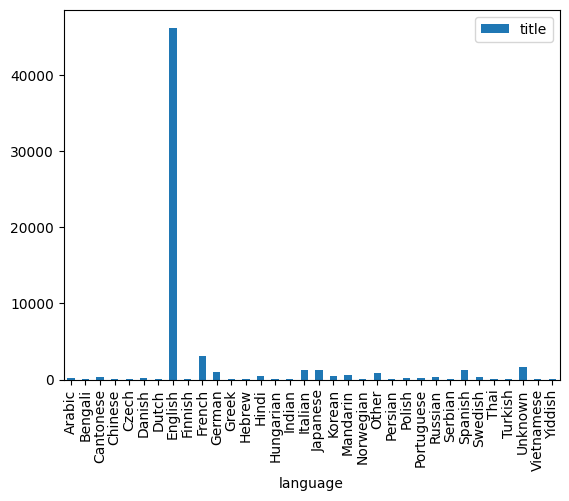

In [ ]:
df.groupby(['language']).count().plot(y='title',kind='bar')

<Axes: xlabel='language'>

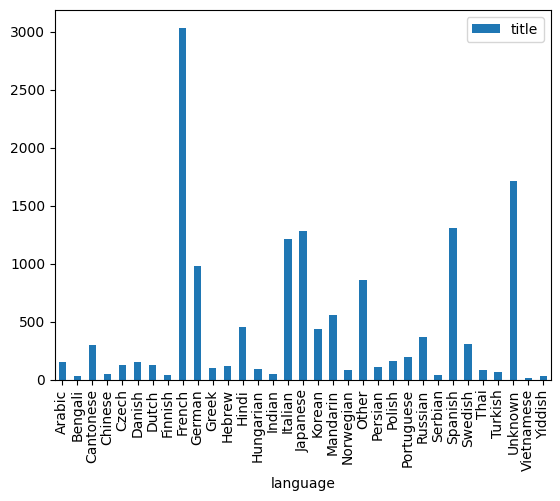

In [ ]:
plotdf = df[df['language'] != 'English']
plotdf.groupby(['language']).count().plot(y='title',kind='bar')

<Axes: xlabel='mpaa_rating'>

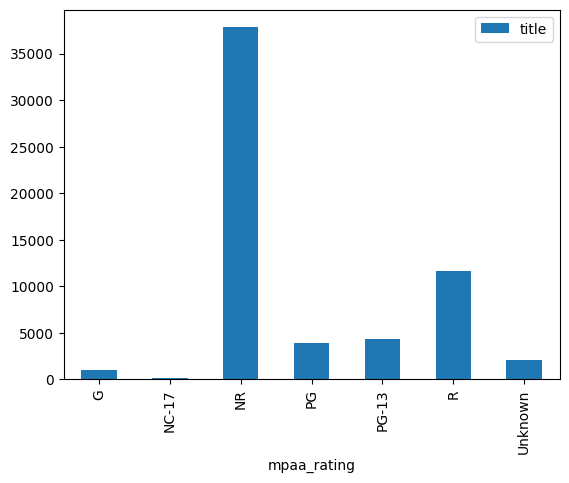

In [ ]:
df.groupby(['mpaa_rating']).count().plot(y='title',kind='bar')

<Axes: xlabel='decade'>

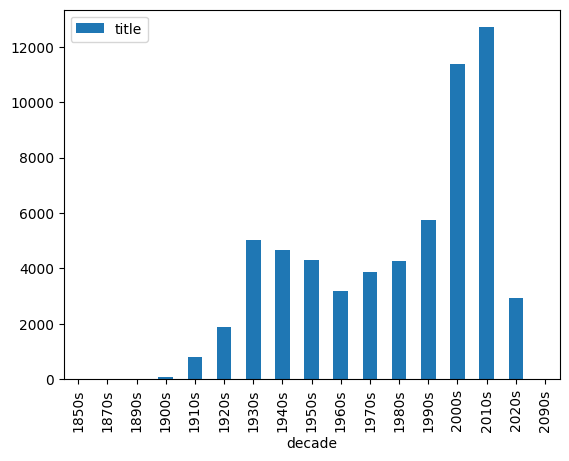

In [ ]:
df.groupby(['decade']).count().plot(y='title',kind='bar')

In [ ]:
df.groupby(['year']).count()

,title,overall_rank,average_rating,theatrical_release_date,language,genres,mpaa_rating,director,actors,plot,decade,genre_main,genre_secondary,filmcrave_id
year,,,,,,,,,,,,,,
1852,1,1,1,1,1,1,1,1,1,1,1,1,0,1
1874,1,1,1,1,1,1,1,1,1,1,1,1,0,1
1878,1,1,1,1,1,1,1,1,1,1,1,1,0,1
1890,2,2,2,2,2,2,2,2,2,2,2,2,1,2
1891,2,2,2,2,2,2,2,2,2,2,2,2,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025,185,185,185,185,185,185,185,185,185,185,185,185,138,185
2026,16,16,16,16,16,16,16,16,16,16,16,16,16,16
2027,1,1,1,1,1,1,1,1,1,1,1,1,1,1


In [ ]:
print(df[df['year'] < 1900][['title', 'year','filmcrave_id']])

                                                   title  year  filmcrave_id
39403                         Annabelle Serpentine Dance  1895         43676
48752                          Cinderella ( Cendrillon )  1899         53074
48758  Four Heads Are Better Than One aka Four Troubl...  1898         53080
48776   House of the Devil, The ( manoir du diable, Le )  1896         53098
48777   After the Ball, the Bath ( Apr\xc3\xa8s le bal )  1897         53099
50588                                       Annie Oakley  1894         54917
50589                                Monkeyshines, No. 1  1890         54918
50590                                   Dickson Greeting  1891         54919
50591                         Sallie Gardner at a Gallop  1878         54920
51555  Temptation of St. Anthony, The ( tentation de ...  1898         55888
51574                    Dickson Experimental Sound Film  1894         55907
51575                                         Carmencita  1894         55908

<Axes: xlabel='year'>

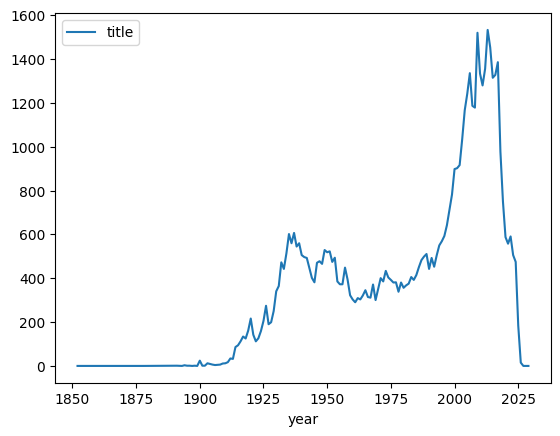

In [ ]:
df.groupby(['year']).count().plot(y='title',kind='line')

In [ ]:
df[df['title'].str.contains('Star Wars')]['title']

2426        Star Wars: Episode V - The Empire Strikes Back
6756            Star Wars: Episode VI - Return of the Jedi
7674                    Star Wars: Episode IV - A New Hope
7675          Star Wars: Episode II - Attack of the Clones
7676             Star Wars: Episode I - The Phantom Menace
7677          Star Wars: Episode III - Revenge of the Sith
18443                                   Saving 'Star Wars'
22089                            Star Wars: The Clone Wars
38563                        The Star Wars Holiday Special
39893    Brazilian Star Wars ( Os Trapalh\xc3\xb5es na ...
40140                   LEGO Star Wars: The Padawan Menace
44398               Lego Star Wars: The Empire Strikes Out
44780                         Star Wars: The Force Awakens
49572          Plastic Galaxy: The Story of Star Wars Toys
50214                             Star Wars: The Last Jedi
50215                         Rogue One: A Star Wars Story
51093                     Star Wars: The Rise of Skywalk

### Word Cloud

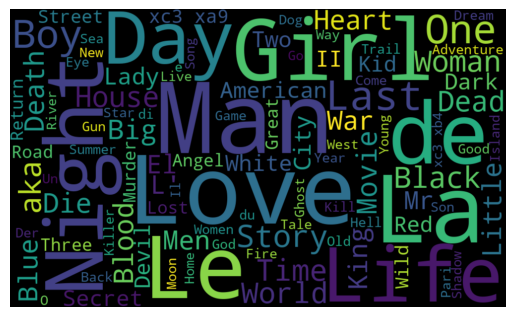

In [ ]:
# Generate Combined Text
text = " ".join(txt for txt in df['title'])

# Create and generate a word cloud image:
wordcloud = WordCloud(max_font_size=200, max_words=100,width=1000,height=600).generate(text)

# Display the word cloud:
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

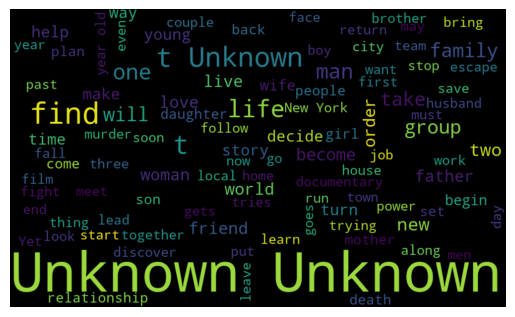

In [ ]:
# Generate Combined Text
text = " ".join(txt for txt in df['plot'])

# Create and generate a word cloud image:
wordcloud = WordCloud(max_font_size=200, max_words=100,width=1000,height=600).generate(text)

# Display the word cloud:
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

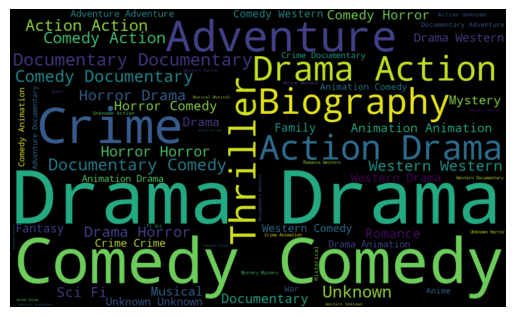

In [ ]:
# Generate Combined Text
text = " ".join(txt for txt in df['genre_main'])

# Create and generate a word cloud image:
wordcloud = WordCloud(max_font_size=200, max_words=100,width=1000,height=600).generate(text)

# Display the word cloud:
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

<Figure size 1000x800 with 0 Axes>

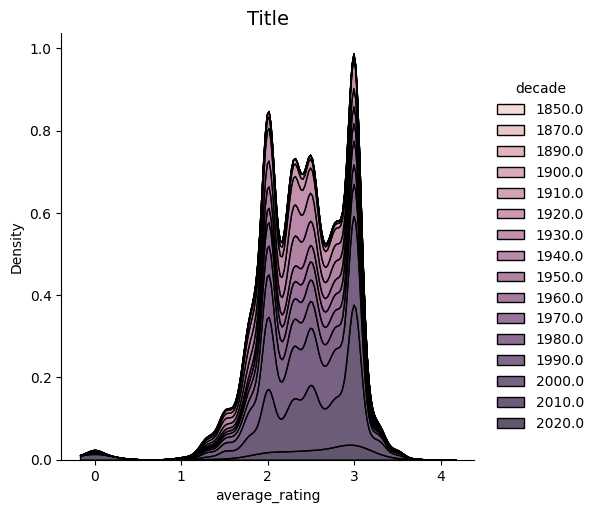

In [ ]:
plt.figure(figsize=(10, 8))
ax = sns.displot(data=df, x='average_rating', hue="decade", multiple="stack", kind="kde", warn_singular=False);
#plt.xlabel('Distribution', fontsize = 12)
plt.title('Title', fontsize = 14)
#plt.rcParams['axes.prop_cycle'] = cycler(color=cmap_terrain_as_list[::32])
plt.show();

<Figure size 1000x800 with 0 Axes>

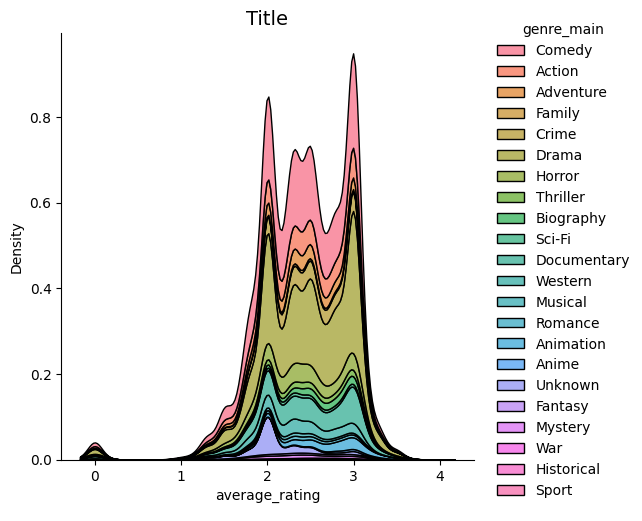

In [ ]:
plt.figure(figsize=(10, 8))
ax = sns.displot(data=df, x='average_rating', hue="genre_main", multiple="stack", kind="kde", warn_singular=False);
#plt.xlabel('Distribution', fontsize = 12)
plt.title('Title', fontsize = 14)
#plt.rcParams['axes.prop_cycle'] = cycler(color=cmap_terrain_as_list[::32])
plt.show();